In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="whitegrid", font_scale=1.0)

TPM_TSV = Path("/data/ddpanchenko/main_dom/komarek/analyses/RNAseq/experiments/RNAseq_analysis/TPM/15DR8/15DR8.genes.results")
MOTIF_MATRIX_TSV = Path("/data/ddpanchenko/main_dom/komarek/analyses/motifs/linear_regression/promoter_TF_sum_pvalue_H13.tsv")
PROMOTER_METADATA_TSV = Path("/data/ddpanchenko/main_dom/komarek/analyses/motifs/linear_regression/data/protein_coding_promoters_500bp.bed")
TARGET_COL = "TPM"
TEST_SIZE = 0.10
RANDOM_STATE = 42
ONLY_NONZERO_TPM = False


In [2]:
MATRIX_PATH = Path("../data/processed/motif_matrices/promoter_motif_M_woTFTPM0.csv")

TARGET_COL = "log2_TPM_plus1"
ID_COLS = ["promoter_id", "gene_id"]

TEST_SIZE = 0.10
RANDOM_STATE = 42

Index(['name', 'original_motif', 'masterlist_info', 'tf', 'collection',
       'subtype_order', 'datatype', 'quality', 'length', 'num_words',
       'consensus', 'gc_content', 'information_content_total',
       'information_content_per_base', 'pcm', 'pwm', 'pfm', 'metrics_summary',
       'standard_thresholds'],
      dtype='object')

In [3]:
df = pd.read_csv(MATRIX_PATH)

print("Matrix shape:", df.shape)
print("Target column exists:", TARGET_COL in df.columns)

df[["promoter_id", "gene_id", TARGET_COL]].head()

motif matrix shape: (20089, 652)


,promoter_id,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC23.H13CORE.0.M.C,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A
0,gene-OR4F16|OR4F16|NC_060925.1:112376-113377|-,98.783361,6.764878,7.546841,74.871164,120.951944,1.139369,30.151835,76.124786,8.736484,...,0.000000,10.881617,1.636851,15.900756,0.000000,62.482981,0.0,3.808357,19.641731,6.489324
1,gene-SAMD11|SAMD11|NC_060925.1:353065-354066|+,9.772065,44.829338,0.000000,27.724477,13.109961,71.539635,34.614253,67.067104,63.827851,...,0.000000,65.955227,0.000000,69.779857,2.049938,85.025793,0.0,23.440861,174.757859,73.622814
2,gene-NOC2L|NOC2L|NC_060925.1:387540-388541|-,15.408038,65.629296,0.000000,24.156025,37.246841,76.151254,49.997986,75.628291,78.284751,...,3.228176,62.462223,0.000000,86.525315,0.000000,122.866271,0.0,20.985361,133.469937,42.800832
3,gene-KLHL17|KLHL17|NC_060925.1:388873-389874|+,0.000000,22.035361,0.000000,12.042646,5.978619,122.110393,12.748931,36.772975,56.440658,...,0.000000,56.940842,0.000000,105.303827,0.000000,146.898805,0.0,15.252057,153.237905,78.218111
4,gene-PLEKHN1|PLEKHN1|NC_060925.1:394692-395693|+,0.000000,58.056269,0.000000,28.862948,15.316276,129.888626,67.134651,124.953253,34.730778,...,0.000000,64.858953,1.249745,84.701314,1.428121,111.118455,0.0,30.943953,157.723171,72.962668


In [4]:
df = df.dropna(subset=[TARGET_COL]).copy()

feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [TARGET_COL]
]

X = df[feature_cols]
y = df[TARGET_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing X values:", X.isna().sum().sum())
print("Missing y values:", y.isna().sum())

,promoter_id,gene_id
0,gene-OR4F16|OR4F16|NC_060925.1:112376-113377|-,gene-OR4F16
1,gene-SAMD11|SAMD11|NC_060925.1:353065-354066|+,gene-SAMD11
2,gene-NOC2L|NOC2L|NC_060925.1:387540-388541|-,gene-NOC2L
3,gene-KLHL17|KLHL17|NC_060925.1:388873-389874|+,gene-KLHL17
4,gene-PLEKHN1|PLEKHN1|NC_060925.1:394692-395693|+,gene-PLEKHN1


In [5]:
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    df[ID_COLS],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

merged shape: (20089, 659)


,promoter_id,gene_id,TPM,FPKM,expected_count,length,effective_length,transcript_id(s),AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,...,ZSC23.H13CORE.0.M.C,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A
4,gene-PLEKHN1|PLEKHN1|NC_060925.1:394692-395693|+,gene-PLEKHN1,0.0,0.0,0.0,2630.40,2402.47,"rna-NM_001160184.2,rna-NM_001367552.1,rna-NM_0...",0.000000,58.056269,...,0.000000,64.858953,1.249745,84.701314,1.428121,111.118455,0.0,30.943953,157.723171,72.962668
5,gene-PERM1|PERM1|NC_060925.1:411432-412433|-,gene-PERM1,0.0,0.0,0.0,3399.00,3171.07,"rna-NM_001291366.2,rna-NM_001291367.2,rna-NM_0...",16.962133,24.168601,...,0.000000,57.669413,0.000000,88.353394,2.320658,113.140422,0.0,16.199792,146.466824,42.994006
11,gene-TTLL10|TTLL10|NC_060925.1:601976-602977|+,gene-TTLL10,0.0,0.0,0.0,2148.17,1920.24,"rna-NM_001130045.2,rna-NM_001371649.1,rna-NM_1...",0.000000,42.861940,...,0.000000,65.739520,0.000000,80.666352,1.064208,176.381856,0.0,54.444638,154.699762,27.937733
12,gene-TNFRSF18|TNFRSF18|NC_060925.1:634548-6355...,gene-TNFRSF18,0.0,0.0,0.0,1041.25,813.32,"rna-NM_004195.3,rna-NM_148901.2,rna-NM_148902....",5.242535,39.373316,...,0.000000,50.061299,2.961196,58.215183,0.000000,156.077053,0.0,35.609834,151.719380,86.600810
36,gene-TMEM240|TMEM240|NC_060925.1:974627-975628|-,gene-TMEM240,0.0,0.0,0.0,1381.00,1153.07,rna-NM_001114748.2,0.000000,30.928352,...,0.000000,46.581322,0.000000,99.160310,0.000000,154.167878,0.0,142.019119,268.317384,75.753069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20080,gene-DAZ4|DAZ4|NC_060948.1:25640970-25641971|-,gene-DAZ4,0.0,0.0,0.0,3770.00,3542.07,"rna-NM_001005375.3,rna-NM_001388484.1,rna-NM_0...",48.722676,62.478313,...,3.605353,38.471116,0.000000,66.735471,8.782415,89.863969,0.0,24.621452,83.858913,40.559633
20081,gene-DAZ2|DAZ2|NC_060948.1:25661320-25662321|+,gene-DAZ2,0.0,0.0,0.0,3595.71,3367.79,"rna-NM_001005785.2,rna-NM_001005786.2,rna-NM_0...",41.037151,68.766553,...,3.605353,39.741625,0.000000,69.923303,8.782415,97.964826,0.0,24.080237,82.819253,40.559633
20082,gene-BPY2C|BPY2C|NC_060948.1:25863999-25865000|-,gene-BPY2C,0.0,0.0,0.0,1206.00,978.07,rna-NM_001002761.1,43.462771,24.520719,...,2.019971,20.314794,0.000000,26.503427,0.000000,78.249896,0.0,14.096347,47.978591,10.843446
20083,gene-CDY1|CDY1|NC_060948.1:26434007-26435008|+,gene-CDY1,0.0,0.0,0.0,2252.00,2024.07,"rna-NM_004680.3,rna-NM_170723.2,rna-XM_0543283...",109.121662,11.466714,...,1.596048,41.940802,6.253279,24.444682,0.000000,57.793532,0.0,8.629229,18.719982,14.386012


In [6]:
models = {
    "Linear regression": LinearRegression(),
    "Ridge regression": RidgeCV(alphas=np.logspace(-3, 3, 20)),
    "Elastic net": ElasticNetCV(
        alphas=np.logspace(-3, 1, 20),
        l1_ratio=[0.1, 0.5, 0.9],
        max_iter=10000,
        random_state=RANDOM_STATE
    )
}

results = []
predictions = {}

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    predictions[name] = y_pred

    results.append({
        "model": name,
        "pearson": pearsonr(y_test, y_pred)[0],
        "spearman": spearmanr(y_test, y_pred)[0],
        "r2": r2_score(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values("pearson", ascending=False)
results_df

working shape: (20007, 659)


,promoter_id,gene_id,TPM,log2_TPM_plus1
0,gene-OR4F16|OR4F16|NC_060925.1:112376-113377|-,gene-OR4F16,0.11,0.150560
1,gene-SAMD11|SAMD11|NC_060925.1:353065-354066|+,gene-SAMD11,40.12,5.361768
2,gene-NOC2L|NOC2L|NC_060925.1:387540-388541|-,gene-NOC2L,221.12,7.795195
3,gene-KLHL17|KLHL17|NC_060925.1:388873-389874|+,gene-KLHL17,24.88,4.693766
4,gene-PLEKHN1|PLEKHN1|NC_060925.1:394692-395693|+,gene-PLEKHN1,0.00,0.000000


In [7]:
models = {
    "Linear regression": LinearRegression(),
    "Ridge regression": RidgeCV(alphas=np.logspace(-3, 3, 20)),
    "Elastic net": ElasticNetCV(
        alphas=np.logspace(-3, 1, 20),
        l1_ratio=[0.1, 0.5, 0.9],
        max_iter=10000,
        random_state=RANDOM_STATE
    )
}

results = []
predictions = {}

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    predictions[name] = y_pred

    results.append({
        "model": name,
        "pearson": pearsonr(y_test, y_pred)[0],
        "spearman": spearmanr(y_test, y_pred)[0],
        "r2": r2_score(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values("pearson", ascending=False)
results_df

{'tf': 'ZN821',
 'tfclass_id': '0.0.9.0.1',
 'tfclass_superclass': 'Yet undefined DNA-binding domains',
 'tfclass_class': 'Uncharacterized',
 'tfclass_family': 'Unannotated',
 'tfclass_subfamily': None,
 'greco_db_tf': 'yes',
 'species': {'HUMAN': {'gene_symbol': 'ZN821',
   'gene_synonyms': [],
   'uniprot_id': 'ZN821_HUMAN',
   'uniprot_ac': 'O75541',
   'protein_name': 'Zinc finger protein 821',
   'hgnc': ['28043'],
   'mgi': [],
   'entrez': ['55565'],
   'tfclass_source': 'manual'},
  'MOUSE': {'gene_symbol': 'Zn821',
   'gene_synonyms': ['Zfp821'],
   'uniprot_id': 'ZN821_MOUSE',
   'uniprot_ac': 'Q6PD05',
   'protein_name': 'Zinc finger protein 821',
   'hgnc': [],
   'mgi': ['1923121'],
   'entrez': [],
   'tfclass_source': 'manual'}}}

In [8]:
def get_human_gene_symbol(masterlist_info):
    try:
        return masterlist_info["species"]["HUMAN"]["gene_symbol"]
    except (KeyError, TypeError):
        return np.nan

TF_DICT = (
    ann
    .set_index("name")["masterlist_info"]
    .apply(get_human_gene_symbol)
    .to_dict()
)

In [9]:
TF_DICT["ZN821.H13CORE.0.SM.B"]

'ZN821'

In [10]:
TF_TPM_MIN = 1
KEEP_UNMAPPED_TF = True 

metadata_cols = {
    "promoter_id",
    "gene_id",
    "TPM",
    "FPKM",
    "expected_count",
    "length",
    "effective_length",
    "transcript_id(s)",
    "log2_TPM_plus1",
}

candidate_feature_cols = [
    c for c in df.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(df[c])
]

expr_with_symbol = expr_df.copy()
expr_with_symbol["gene_symbol"] = expr_with_symbol["gene_id"].str.replace(
    "^gene-", "", regex=True
)

tf_tpm = (
    expr_with_symbol
    .groupby("gene_symbol")["TPM"]
    .max()
)

motif_info = pd.DataFrame({"feature": candidate_feature_cols})
motif_info["motif_symbol"] = motif_info["feature"].str.split(".H13CORE", regex=False).str[0]
motif_info["gene_symbol"] = motif_info["feature"].replace(TF_DICT)
motif_info["tf_TPM"] = motif_info["gene_symbol"].map(tf_tpm)

motif_info["tf_is_expressed"] = motif_info["tf_TPM"] >= TF_TPM_MIN
motif_info["tf_is_unmapped"] = motif_info["tf_TPM"].isna()

if KEEP_UNMAPPED_TF:
    keep_mask = motif_info["tf_is_expressed"] | motif_info["tf_is_unmapped"]
else:
    keep_mask = motif_info["tf_is_expressed"]

feature_cols = motif_info.loc[keep_mask, "feature"].tolist()
# feature_cols = candidate_feature_cols

print("candidate motif features:", len(candidate_feature_cols))
print("kept motif features:", len(feature_cols))
print("dropped motif features:", len(candidate_feature_cols) - len(feature_cols))
print("unmapped motif features:", motif_info["tf_is_unmapped"].sum())

motif_info.sort_values(["tf_is_unmapped", "tf_TPM", "motif_symbol"])


candidate motif features: 651
kept motif features: 509
dropped motif features: 142
unmapped motif features: 5


,feature,motif_symbol,gene_symbol,tf_TPM,tf_is_expressed,tf_is_unmapped
12,BATF.H13CORE.0.P.B,BATF,BATF,0.0,False,False
23,CPXCR1.H13CORE.0.P.C,CPXCR1,CPXCR1,0.0,False,False
37,DUX4.H13CORE.0.P.B,DUX4,DUX4,0.0,False,False
44,FER3L.H13CORE.0.SM.B,FER3L,FERD3L,0.0,False,False
45,FEZF1.H13CORE.0.P.B,FEZF1,FEZF1,0.0,False,False
...,...,...,...,...,...,...
485,ZN681.H13CORE.0.P.C,ZN681,ZNF681,NaN,False,True
524,ZN821.H13CORE.0.SM.B,ZN821,ZN821,NaN,False,True
552,ZNF286B.H13CORE.0.PSG.A,ZNF286B,ZNF286B,NaN,False,True
600,ZNF705EP.H13CORE.0.P.B,ZNF705EP,ZNF705EP,NaN,False,True


In [12]:
print(len(feature_cols))
import csv        

data = ['text1', 'text2', 'text3', 'text4']    

with open('/data/ddpanchenko/main_dom/komarek/analyses/motifs/promoter-motif-project/data/representative_pwm_ids_wo_0TPM.txt', 'w', newline='') as f_output:
    tsv_output = csv.writer(f_output, delimiter='\n')
    tsv_output.writerow(feature_cols)

509


In [83]:
print("number of motif features:", len(feature_cols))
print(feature_cols[:10])

X = df[feature_cols].fillna(0.0)
y = df["log2_TPM_plus1"]


number of motif features: 509
['AHCTF1.H13CORE.0.B.B', 'AHR.H13CORE.0.P.B', 'ALX1.H13CORE.0.SM.B', 'ANDR.H13CORE.1.S.C', 'ANDR.H13CORE.2.P.B', 'AP2A.H13CORE.0.PSM.A', 'ARNT.H13CORE.0.P.B', 'ARNT2.H13CORE.0.P.B', 'ATF1.H13CORE.1.P.B', 'ATMIN.H13CORE.0.P.B']


In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print("train shape:", X_train.shape)
print("test shape:", X_test.shape)


train shape: (18006, 509)
test shape: (2001, 509)


In [85]:
models = {
    "ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 3, 20))),
    ]),
    "elastic_net": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-3, 1, 12),
            cv=5,
            max_iter=10000,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "linear": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
}


In [86]:
results = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    pearson_r, pearson_p = pearsonr(y_test, y_pred)
    spearman_rho, spearman_p = spearmanr(y_test, y_pred)

    results.append({
        "model": model_name,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "r2": r2_score(y_test, y_pred),
        "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
        "mae": mean_absolute_error(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("pearson_r", ascending=False)
results_df


/home/ddpanchenko/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18.69473552350246, tolerance: 9.562984674212911
  model = cd_fast.enet_coordinate_descent_gram(
/home/ddpanchenko/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 19.886406686935516, tolerance: 9.505316356639005
  model = cd_fast.enet_coordinate_descent_gram(
/home/ddpanchenko/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 19.353104718546092, tolerance: 9.384578197428516
  model = cd_fast.enet_coordinate_descent_gram(
/home/ddpanchenko/miniforge3/lib/python3.12/sit

,model,pearson_r,pearson_p,spearman_rho,spearman_p,r2,rmse,mae
0,ridge,0.604996,4.402734e-200,0.641420,2.316151e-232,0.364730,2.031960,1.586719
1,elastic_net,0.603834,4.026762e-199,0.638544,1.182615e-229,0.363558,2.033832,1.593100
2,linear,0.602494,5.115092e-198,0.638627,9.891918e-230,0.360784,2.038261,1.586289


best model by Pearson correlation: ridge


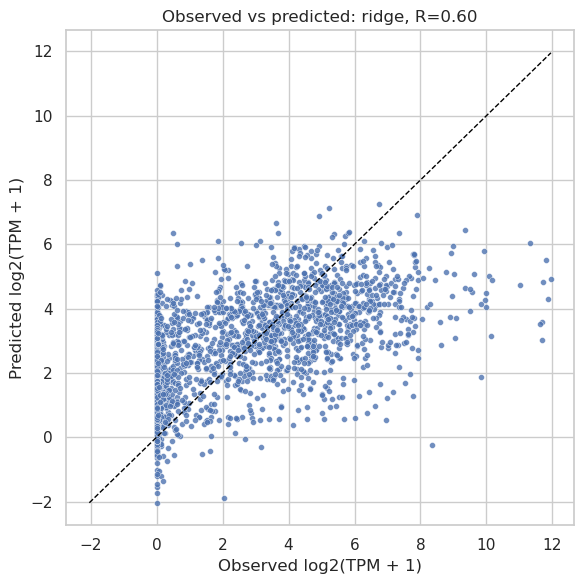

In [87]:
best_model_name = results_df.iloc[0]["model"]
print("best model by Pearson correlation:", best_model_name)

pred_df = pd.DataFrame({
    "observed": y_test.to_numpy(),
    "predicted": predictions[best_model_name],
    "pearson_r": pearson_r,
    "spearman_rho": spearman_rho,
})

plt.figure(figsize=(6, 6))
ax = sns.scatterplot(data=pred_df, x="observed", y="predicted", s=18, alpha=0.8)
lims = [
    min(pred_df.min().min(), pred_df.max().min()),
    max(pred_df.max().max(), pred_df.min().max()),
]
plt.plot(lims, lims, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Observed vs predicted: {best_model_name}, R={pearson_r:.2f}")
ax.set_xlabel("Observed log2(TPM + 1)")
ax.set_ylabel("Predicted log2(TPM + 1)")
plt.tight_layout()
plt.show()


In [88]:
len(y_test.values)

2001

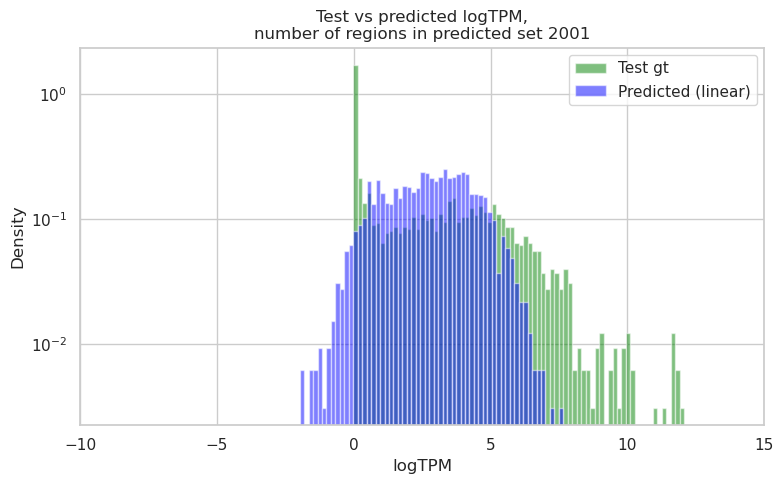

In [108]:
train_vals = y_train.values
test_vals = y_test.values
pred_vals_linear = predictions["linear"]

bins = np.histogram_bin_edges(
    np.concatenate([train_vals, test_vals, pred_vals_linear]),
    bins=100
)

plt.figure(figsize=(8, 5))
# plt.hist(train_vals, bins=bins, alpha=0.5, density=True, label="Train logTPM")
plt.hist(test_vals, bins=bins, alpha=0.5, density=True, label="Test gt", color="green")
plt.hist(pred_vals_linear, bins=bins, alpha=0.5, density=True, label="Predicted (linear)", color="blue")

plt.xlabel("logTPM")
plt.ylabel("Density")
plt.title(f"Test vs predicted logTPM,\nnumber of regions in predicted set {len(pred_vals_linear)}")
plt.yscale("log")
plt.xlim(-10, 15)
plt.xlim(-10, 15)
plt.legend()
plt.tight_layout()
plt.show()

### Predict TPMs for mosquito promoters

In [102]:
mos_promoter_df = pd.read_csv(
    "/data/ddpanchenko/main_dom/komarek/analyses/motifs/linear_regression/promoter_TF_sum_pvalue_intergenic.tsv",
    sep="\t"
)
mos_promoter_df.head()


,promoter_id,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC23.H13CORE.0.M.C,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A
0,chr1:4130433-4131433,14.456662,32.181988,0.000000,13.963973,28.930652,8.668146,35.403409,108.562069,24.620910,...,0.000000,23.659519,2.796305,53.206026,0.000000,84.642460,0.0,42.737891,134.580780,25.325981
1,chr1:4439459-4440459,56.834416,5.560699,4.596243,50.167999,96.412626,2.743187,15.264176,77.463607,11.190236,...,1.442879,37.366203,0.000000,26.499262,4.106775,85.010754,0.0,9.976928,30.722696,25.191145
2,chr1:7682721-7683721,70.047725,24.885444,2.201218,33.454436,89.805113,12.633571,31.745309,91.687939,16.624773,...,0.000000,35.020732,0.000000,40.587843,0.000000,83.296988,0.0,17.722242,33.544194,30.944929
3,chr1:10432374-10433374,0.000000,21.614282,0.000000,10.938966,29.442579,77.667433,19.512708,69.870101,41.418103,...,0.000000,60.942441,0.000000,97.613689,0.000000,141.227711,0.0,89.331170,225.243366,90.571961
4,chr1:10954422-10955422,59.467766,10.565095,0.000000,48.488455,102.690396,2.919854,15.236585,59.185121,16.567519,...,4.108086,13.944027,2.240461,39.527260,4.328519,69.904946,0.0,50.885567,57.854870,25.655336


In [103]:
mos_promoter_df = mos_promoter_df.set_index(mos_promoter_df.columns[0])
mos_promoters = mos_promoter_df[feature_cols].fillna(0.0)

X_mos = mos_promoters.reindex(
    columns=X_train.columns,
    fill_value=0.0
)
X_mos

,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,ATMIN.H13CORE.0.P.B,...,ZSC21.H13CORE.0.P.C,ZSC22.H13CORE.0.P.C,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A
promoter_id,,,,,,,,,,,,,,,,,,,,,
chr1:4130433-4131433,14.456662,32.181988,0.000000,13.963973,28.930652,8.668146,35.403409,108.562069,24.620910,178.325727,...,159.264736,67.050119,23.659519,2.796305,53.206026,84.642460,0.0,42.737891,134.580780,25.325981
chr1:4439459-4440459,56.834416,5.560699,4.596243,50.167999,96.412626,2.743187,15.264176,77.463607,11.190236,110.062648,...,85.471460,32.615025,37.366203,0.000000,26.499262,85.010754,0.0,9.976928,30.722696,25.191145
chr1:7682721-7683721,70.047725,24.885444,2.201218,33.454436,89.805113,12.633571,31.745309,91.687939,16.624773,66.013954,...,101.687462,52.208108,35.020732,0.000000,40.587843,83.296988,0.0,17.722242,33.544194,30.944929
chr1:10432374-10433374,0.000000,21.614282,0.000000,10.938966,29.442579,77.667433,19.512708,69.870101,41.418103,742.927056,...,57.156564,193.849165,60.942441,0.000000,97.613689,141.227711,0.0,89.331170,225.243366,90.571961
chr1:10954422-10955422,59.467766,10.565095,0.000000,48.488455,102.690396,2.919854,15.236585,59.185121,16.567519,200.919790,...,112.191761,80.902350,13.944027,2.240461,39.527260,69.904946,0.0,50.885567,57.854870,25.655336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrY:55661081-55662081,63.805753,6.306606,18.891837,70.708126,44.666571,0.000000,1.393031,22.591053,7.825429,49.073643,...,34.041276,7.022892,10.688589,0.000000,5.926980,5.819405,0.0,1.006927,6.158113,1.509698
chrY:61074484-61075484,129.638151,0.000000,3.906611,45.305990,153.829275,0.000000,9.819658,16.815284,0.000000,0.000000,...,5.584348,1.780781,2.121451,4.914233,1.956751,1.661777,0.0,0.000000,0.000000,0.000000
chrY:62065354-62066354,21.922967,14.357365,6.035652,47.449326,19.634939,3.541905,6.520546,28.617336,11.844109,111.295181,...,53.490544,18.675771,8.586137,0.000000,24.461782,27.324804,0.0,121.827174,24.964405,0.000000


In [104]:
mos_predictions = pd.DataFrame(index=X_mos.index)
mos_predictions

""
promoter_id
chr1:4130433-4131433
chr1:4439459-4440459
chr1:7682721-7683721
chr1:10432374-10433374
chr1:10954422-10955422
...
chrY:55661081-55662081
chrY:61074484-61075484
chrY:62065354-62066354


In [105]:
for model_name, model in models.items():
    mos_predictions[f"pred_logTPM_{model_name}"] = model.predict(X_mos)

# Sort by linear model prediction
mos_predictions = mos_predictions.sort_values(
    "pred_logTPM_linear",
    ascending=False
)

mos_predictions.head(20)

,pred_logTPM_ridge,pred_logTPM_elastic_net,pred_logTPM_linear
promoter_id,,,
chrY:62458392-62459392,19.774564,16.719710,17.165083
chr22:5114263-5115263,5.328552,5.053450,5.353502
chr22:41565669-41566669,5.033457,4.990941,4.837671
chr16:81479377-81480377,4.045873,4.114039,4.273105
chr7:35595329-35596329,3.917814,3.690835,4.099925
chr9:116025723-116026723,3.223781,2.105827,3.891760
chr3:5913493-5914493,3.546467,3.045176,3.858625
chr19:38246458-38247458,3.794388,3.734409,3.789394
chr16:30997757-30998757,3.641663,3.310989,3.729063


/tmp/ipykernel_1523246/2338414082.py:18: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 15)


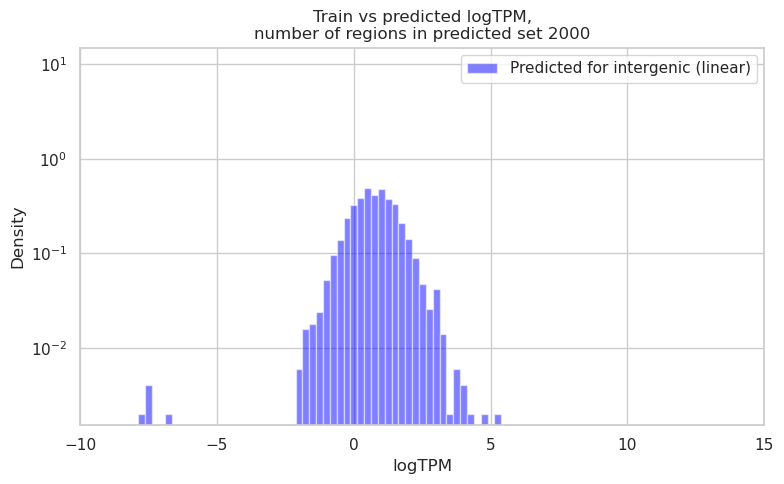

In [107]:
import matplotlib.pyplot as plt

train_vals = y_train.values
pred_vals = mos_predictions["pred_logTPM_linear"].values

bins = np.histogram_bin_edges(np.concatenate([train_vals, pred_vals]), bins=100)

plt.figure(figsize=(8, 5))
# plt.hist(train_vals, bins=bins, alpha=0.5, density=True, label="Train logTPM")
plt.hist(pred_vals, bins=bins, alpha=0.5, density=True, label="Predicted for intergenic (linear)", color="blue")

plt.xlabel("logTPM")
plt.ylabel("Density")
plt.title(f"Train vs predicted logTPM,\nnumber of regions in predicted set {len(pred_vals)}")
plt.legend()
plt.yscale("log")
plt.xlim(-10, 15)
plt.ylim(0, 15)
plt.tight_layout()
plt.show()